In [1]:
import os
os.chdir("../dgl_ptm/")

import sys
import zarr
import time
import pickle
import random
import dgl_ptm
import numpy as np
import networkx as nx

import osmnx as ox
import folium

import geopandas as gpd
import shapely
from shapely.geometry import Polygon, box, Point
import contextily as ctx

from matplotlib.animation import FuncAnimation
import imageio
from PIL import Image


from tqdm.auto import tqdm
from dgl_ptm.util.utils import sample_distribution_tensor

os.environ["DGLBACKEND"] = "pytorch"
import torch

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker


from collections import Counter
import matplotlib
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({"font.size" : 15,
                     "figure.dpi" : 100, 
                     "grid.alpha" : 0.3, 
                     "axes.grid": True, 
                     "axes.axisbelow" : True,
                     "figure.figsize":(8,6),
                     "mathtext.fontset":"cm",
                     "xtick.labelsize": 14,
                     "ytick.labelsize": 14,
                     "axes.labelsize": 16, 
                     "legend.fontsize": 13.5})
plt.rc("text", usetex=False)
plt.rc("font", family="serif")

### Grid Construction

In [2]:
size = 75

In [3]:
# Step 1: Manually Define Akuse's Boundary (Example Coordinates)
akuse_boundary_coords = [ (x[1],x[0]) for x in [
        (6.107983818842101, 0.11640835827890646),
        (6.106918939321614, 0.13688109260416578),
        (6.095601368066649, 0.13518748441180858),
        (6.090648307705022, 0.11628382826476255)
    ] 
]

boundary = Polygon(akuse_boundary_coords)
gdf = gpd.GeoDataFrame(geometry=[boundary], crs="EPSG:4326")  # WGS84 CRS

# Step 2: Create Grid within the Boundary
def create_grid(bounds, num_cells=size):
    """Generate a grid of square polygons within given bounds."""
    minx, miny, maxx, maxy = bounds
    x_coords = np.linspace(minx, maxx, num_cells)
    y_coords = np.linspace(miny, maxy, num_cells)
    grid_cells = []
    ydelta = (maxy - miny) / num_cells
    xdelta = (maxx-minx) / num_cells
    for x in x_coords:
        for y in y_coords:
            cell = box(x, y, x + xdelta, y + ydelta)
            if cell.intersects(boundary):  # Keep only cells inside Akuse
                grid_cells.append(cell)

    return gpd.GeoDataFrame(geometry=grid_cells, crs="EPSG:4326")

grid = create_grid(boundary.bounds)

# Step 3: Plot the Result
# fig, ax = plt.subplots(figsize=(12, 12))
# grid.plot(ax=ax, edgecolor="k", facecolor="none", linewidth=0.5, alpha=0.3)
# ctx.add_basemap(ax, crs=gdf.crs, source=ctx.providers.OpenStreetMap.Mapnik)
# plt.title("Akuse, Ghana")
# plt.xticks([])
# plt.yticks([])
# plt.savefig("rasterised_akuse.png", bbox_inches="tight")
# plt.show()

### Population Density Grid

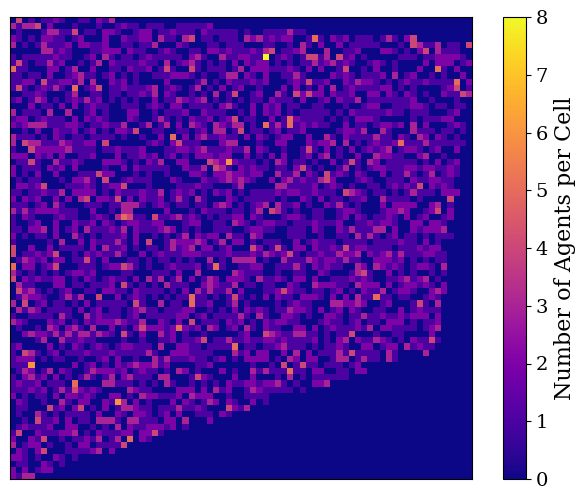

In [4]:
boundary = Polygon(akuse_boundary_coords)
gdf = gpd.GeoDataFrame(geometry=[boundary], crs="EPSG:4326")

# Step 2: Define Grid Over Bounding Box
rows, cols = size, size  # Define the shape
minx, miny, maxx, maxy = boundary.bounds
x_step = (maxx - minx) / cols  # Cell width
y_step = (maxy - miny) / rows  # Cell height

# Step 3: Create Grid and Populate NumPy Array
grid_array = np.zeros((rows, cols, 1), dtype=np.uint8)

for i in range(rows):
    for j in range(cols):
        x_start = minx + j * x_step
        y_start = miny + i * y_step
        cell = box(x_start, y_start, x_start + x_step, y_start + y_step)
        if cell.intersects(boundary):  # If cell intersects Akuse, set to 1
            grid_array[i, j, 0] = 1

valid_cells = np.argwhere(grid_array[:, :, 0] == 1)
num_valid_cells = len(valid_cells)
allocations = np.random.multinomial(5000, np.ones(num_valid_cells) / num_valid_cells)
distributed_grid = np.zeros((size, size, 1), dtype=np.int32)
for i, (row, col) in enumerate(valid_cells):
    distributed_grid[row, col, 0] = allocations[i]

plt.imshow(distributed_grid[:, :, 0], cmap="plasma", origin="lower")
plt.colorbar(label="Number of Agents per Cell")
plt.xticks([])
plt.yticks([])
plt.show()

### Locations of Interest Grid

In [5]:
point = (6.100635676379143, 0.12736045405150456)
radius = 1000
tags = {"amenity": ["school", "place_of_worship"]}
gdf = ox.features_from_point(point, tags, dist=radius)

f = folium.Figure(width=750, height=400)
m = folium.Map(location=point, zoom_start=16).add_to(f)
for _, row in gdf.iterrows():
    folium.GeoJson(row['geometry']).add_to(m)

LOI = {}
for _, row in gdf.iterrows():
    amenity_type = row["amenity"]
    if amenity_type not in LOI:
        LOI[amenity_type] = []
    LOI[amenity_type].append((row["geometry"].centroid.x, row["geometry"].centroid.y))

# m

In [6]:
# import io
# from PIL import Image
# import selenium

# img_data = m._to_png(5)
# img = Image.open(io.BytesIO(img_data))
# img.save('locations_of_interest.png')

In [7]:
for category, locations_of_interest in LOI.items():
    grid_array = np.zeros((rows, cols), dtype=np.uint8)
    location_to_cell = {}
    
    for lon, lat in locations_of_interest:
        point = Point(lon, lat)  # Convert to a Shapely point
        
        for i in range(size):  # Loop over rows
            for j in range(size):  # Loop over columns
                x_start = minx + j * x_step
                y_start = miny + i * y_step
                cell = box(x_start, y_start, x_start + x_step, y_start + y_step)  # Define the cell
                
                if cell.contains(point):  # Check if point is inside the cell
                    location_to_cell[(lon, lat)] = (i, j)  # Store row, col indices 
                    grid_array[i][j] = 1
                    break

    distributed_grid = np.dstack((distributed_grid.squeeze(), grid_array))

In [8]:
# add water points
occupied_cells = set()
for dim in range(1, distributed_grid.shape[-1]):
    cells = np.column_stack(np.where(distributed_grid[:,:,dim]!=0))
    for row in cells:
        occupied_cells.add(tuple(row))
available_cells = set([tuple(row) for row in valid_cells]) - occupied_cells

num_water_points = 12
water_cells = random.sample(sorted(available_cells), num_water_points)
grid_array = np.zeros((rows, cols), dtype=np.uint8)
for idx in water_cells:
    grid_array[idx] = 1

distributed_grid = np.dstack((distributed_grid.squeeze(), grid_array))

In [9]:
# avoid placing any agent residences directly on top of locations of interest
distributed_grid[:,:,0] = np.where(np.sum(distributed_grid[:,:,1:], axis=2)!=0, 0, distributed_grid[:,:,0])

In [10]:
np.save("grid.npy", distributed_grid)

### Model Creation

In [11]:
properties = {
    "population":0
}

for i,k in enumerate(LOI.keys()):
    properties[k] = i+1

properties["water"] = max(properties.values()) + 1

In [68]:
def create_model (seed=42, identifier="sveir_test", num_agents=10000, steps=100, new_node_edges=5):
    model = dgl_ptm.SVEIRModel(model_identifier=identifier)
    model.set_model_parameters(**{
        'number_agents': num_agents,
        'seed': seed,
        'spatial': True,
        'spatial_creation_args':{
            "method": "custom_import",
            "path": "grid.npy",
            "properties": properties
        },
        'spatial_assignment_args':{'method':"property",'property':"population"},
        'initial_graph_type': 'barabasi-albert',
        'initial_graph_args': {'seed': seed, 'new_node_edges':new_node_edges},
        'device': 'cpu',
        'step_target': steps,
        'steering_parameters': {
            'npath':'./agent_data.zarr',
            'epath':'./edge_data',
            'ndata':[['compartments', 'num_infections', 'x', 'y', 'activity_choice'],['initial_only',[]]],
            'edata': None,
            'mode': 'w',
            'proximity_decay_rate': 0.05,
            'truncation_weight': 1e-10,
            'recovery_rate': 0.1,
            'vaccination_rate': 0.005,
            'vaccine_efficacy': 0.9,
            'exposure_period': 5,

            
            'initial_infected_proportion': 0.0,
            'infection_probability': 0.0,
            'human_to_water_infection_prob': 0.0,
            'water_to_human_infection_prob': 0.5,

            'water_recovery_prob': 0.1,
            'shock_frequency':15,
            'shock_infection_prob':0.7,
            
            'step_type': 'seir'
        }
    })
    model.initialize_model()
    return model

In [69]:
# key = "water_location"

# locations = torch.stack(torch.where(m.grid_environment.grid_tensor[:,:,3])).T.float()
# distances = torch.cdist(m.graph.ndata[key], locations)
# nearest_indices = torch.argmin(distances, dim=1)
# nearest_locations = locations[nearest_indices]


# agent_idx = 13

# plt.scatter(m.graph.ndata["home_location"][agent_idx,1], m.graph.ndata["home_location"][agent_idx,0], marker='x')
# plt.scatter(
#     locations[:,1],
#     locations[:,0]
# )
# plt.scatter(
#     nearest_locations[agent_idx][1],
#     nearest_locations[agent_idx][0],
#     c="green"
# )

# plt.xlim(0,size)
# plt.ylim(0,size)
# plt.show()

### Results

#### Single Run

In [100]:
model = create_model(num_agents=1000, new_node_edges=2, seed=3)
model.run()

In [101]:
mapping = {
    "S":0,
    "V":1,
    "E":2,
    "I":3,
    "R":4
}
rev_mapping = {v:k for k,v in mapping.items()}

In [102]:
compartment_data = zarr.load('./sveir_test/agent_data.zarr/compartments')
X = zarr.load('./sveir_test/agent_data.zarr/x/')
Y = zarr.load('./sveir_test/agent_data.zarr/y/')
activity = zarr.load("./sveir_test/agent_data.zarr/activity_choice/")

In [103]:
SVEIR = {c:[] for c in mapping}
for col in range(compartment_data.shape[1]):
    time_step = compartment_data[:,col]
    counts = dict(Counter(time_step))
    for k in mapping:
        idx = mapping[k]
        if idx in counts:
            SVEIR[k].append(counts[idx])
        else:
            SVEIR[k].append(0)

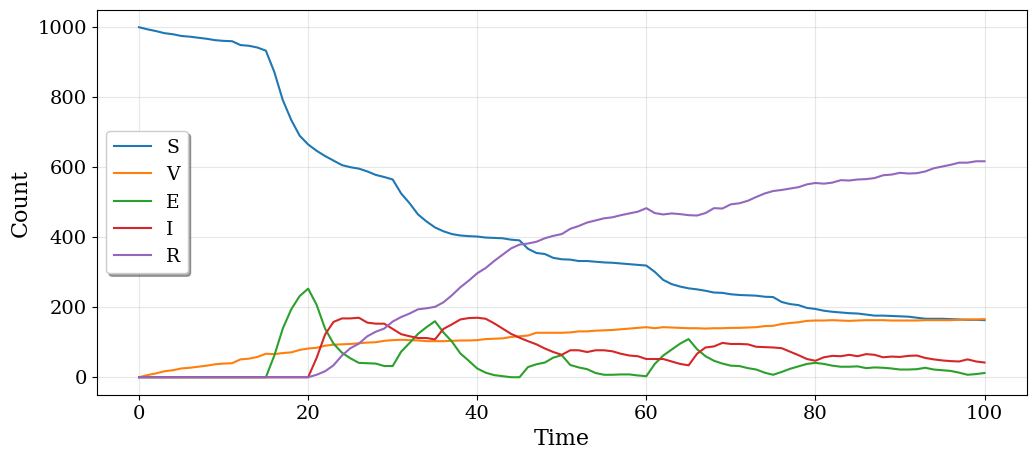

In [104]:
plt.figure(figsize=(12,5))

for c in SVEIR:
    plt.plot(SVEIR[c], label=c)

plt.legend(shadow=True)
plt.xlabel("Time")
plt.ylabel("Count")
plt.savefig("SVEIR_curves.pdf", bbox_inches="tight")
plt.show()

#### Repeated Runs

In [70]:
mapping = {
    "S":0,
    "V":1,
    "E":2,
    "I":3,
    "R":4
}
rev_mapping = {v:k for k,v in mapping.items()}

In [92]:
all_SVEIR = []

for rep in tqdm(range(20)):

    model_id = f"sveir_{rep}"
    model = create_model(num_agents=1000, new_node_edges=2, seed=rep, identifier=model_id)
    model.run()

    compartment_data = zarr.load(f'./{model_id}/agent_data.zarr/compartments')
    X = zarr.load(f'./{model_id}/agent_data.zarr/x/')
    Y = zarr.load(f'./{model_id}/agent_data.zarr/y/')
    activity = zarr.load(f"./{model_id}/agent_data.zarr/activity_choice/")

    SVEIR = {c:[] for c in mapping}
    for col in range(compartment_data.shape[1]):
        time_step = compartment_data[:,col]
        counts = dict(Counter(time_step))
        for k in mapping:
            idx = mapping[k]
            if idx in counts:
                SVEIR[k].append(counts[idx])
            else:
                SVEIR[k].append(0)
                
    all_SVEIR.append(SVEIR)

    infected_mats = []
    for i in range(100):
        infected_agents = np.where(compartment_data[:,i]==3)[0]
        infected_x = X[infected_agents, i]
        infected_y = Y[infected_agents, i]
        infected_coords = np.row_stack([infected_x, infected_y]).T
        mat = np.zeros((size,size))
        for row in infected_coords:
            mat[row.astype(int)[0], row.astype(int)[1]] += 1
        infected_mats.append(mat)

  0%|          | 0/20 [00:00<?, ?it/s]

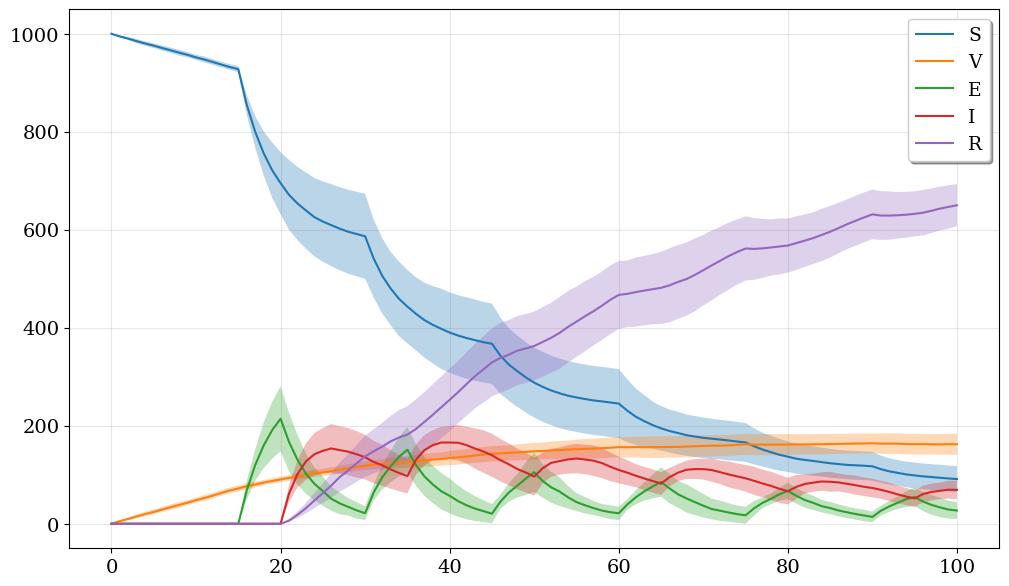

In [73]:
plt.figure(figsize=(12,7))

for k in SVEIR:
    avg = np.mean([item[k] for item in all_SVEIR], axis=0)
    std = np.std([item[k] for item in all_SVEIR], axis=0)
    plt.fill_between(np.arange(compartment_data.shape[1]), y1=np.maximum(avg-std, 0), y2=avg+std, alpha=0.3)
    plt.plot(avg, label=k)
plt.legend(shadow=True)
plt.savefig("seasonal_forcing.pdf", bbox_inches="tight")
plt.show()

### gif

In [105]:
akuse_boundary_coords = [ (x[1],x[0]) for x in [
        (6.107983818842101, 0.11640835827890646),
        (6.106918939321614, 0.13688109260416578),
        (6.095601368066649, 0.13518748441180858),
        (6.090648307705022, 0.11628382826476255)
    ] 
]
boundary = Polygon(akuse_boundary_coords)
minx, miny, maxx, maxy = boundary.bounds
gdf = gpd.GeoDataFrame(geometry=[boundary], crs="EPSG:4326")  # WGS84 CRS

In [109]:
output_dir = "gif"
os.makedirs(output_dir, exist_ok=True)

fig, axs = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [2, 1]})
grid = create_grid(boundary.bounds)

threshold = 2
cmap = plt.get_cmap("plasma")
cmap.set_under(color="white", alpha=0)

MAX_T = 100

global_max = 0
for T in range(MAX_T):  # Change to the full range if needed
    infected_agents = np.where(compartment_data[:, T] == 3)[0]
    infected_coords = np.column_stack([X[infected_agents, T], Y[infected_agents, T]])
    heatmap_grid = np.zeros((size, size), dtype=int)
    for x, y in infected_coords.astype(int):
        heatmap_grid[x, y] += 1
    global_max = max(global_max, heatmap_grid.max())
global_max = max(threshold, global_max)

norm = mcolors.Normalize(vmin=threshold, vmax=global_max)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axs[0], orientation="vertical", shrink=0.7)
cbar.set_label("Infected Count")
cbar.locator = ticker.MaxNLocator(integer=True)
cbar.update_ticks()

for T in range(MAX_T):
    axs[0].clear()
    axs[1].clear()

    # Plot the grid and base map again for each frame
    gdf.plot(ax=axs[0], alpha=0.1, color="lightgray")
    ctx.add_basemap(axs[0], crs=gdf.crs, source=ctx.providers.OpenStreetMap.Mapnik)

    # Get the infected agents and their coordinates
    infected_agents = np.where(compartment_data[:, T] == 3)[0]
    infected_coords = np.column_stack([X[infected_agents, T], Y[infected_agents, T]])

    # Create the heatmap grid
    heatmap_grid = np.zeros((size, size), dtype=int)
    for x, y in infected_coords.astype(int):
        heatmap_grid[x, y] += 1

    # Mask the heatmap grid with the threshold
    masked_heatmap = np.ma.masked_where(heatmap_grid < threshold, heatmap_grid)

    # Plot the heatmap using the **static** norm
    axs[0].imshow(masked_heatmap, extent=[minx, maxx, miny, maxy], origin="lower", cmap=cmap, norm=norm, alpha=0.75)
    axs[0].set_xticks([])
    axs[0].set_yticks([])

    # Epidemic curves
    for c in SVEIR:
        axs[1].plot(SVEIR[c][:T+1], label=c)
    axs[1].legend(shadow=True)
    axs[1].set_xlabel("Time")
    axs[1].set_ylabel("Count")
    axs[1].set_xticks(np.linspace(0, 100, 11))

    # Save the image for the current timestep
    fig.suptitle(f"T = {T}", fontsize=18, x=0.3)  # Set overall title
    image_filename = os.path.join(output_dir, f"T_{T:03d}.png")
    fig.savefig(image_filename, bbox_inches='tight', pad_inches=0.1)

# Close the figure to free up memory
plt.close(fig)

In [110]:
output_dir = "gif"

# Create the GIF from saved frames
gif_filename = os.path.join(output_dir, "infection_animation.gif")
image_files = [os.path.join(output_dir, f"T_{T:03d}.png") for T in range(100)]

# Create a list of PIL Image objects
pil_images = [Image.open(image_file) for image_file in image_files]

# Save as a GIF with the desired duration
pil_images[0].save(gif_filename, save_all=True, append_images=pil_images[1:], optimize=False, loop=0, duration=150)

### Profiling

In [3]:
agent_array = [1024, 4096, 16384, 131072, 1048576]
nne_array = [2, 4, 8]

T = {}
avg_deg = []

for nne in nne_array:
    T[nne] = {}
    for n_agents in tqdm(agent_array):
        model = create_model(num_agents=n_agents, new_node_edges=nne)
        if n_agents == agent_array[-1]:
            G = model.graph.to_networkx()
            avg_deg.append(round(sum(dict(G.degree()).values()) / n_agents))
        time_start = time.time()
        model.run()
        T[nne][n_agents] = time.time() - time_start

# with open("../DGL_testing/profiling_results.pickle", "wb") as f:
#     pickle.dump({
#         "avg_deg": avg_deg,
#         "time": T
#     }, f)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

In [3]:
with open("../DGL_testing/profiling_results.pickle", "rb") as f:
    profiling_result = pickle.load(f)

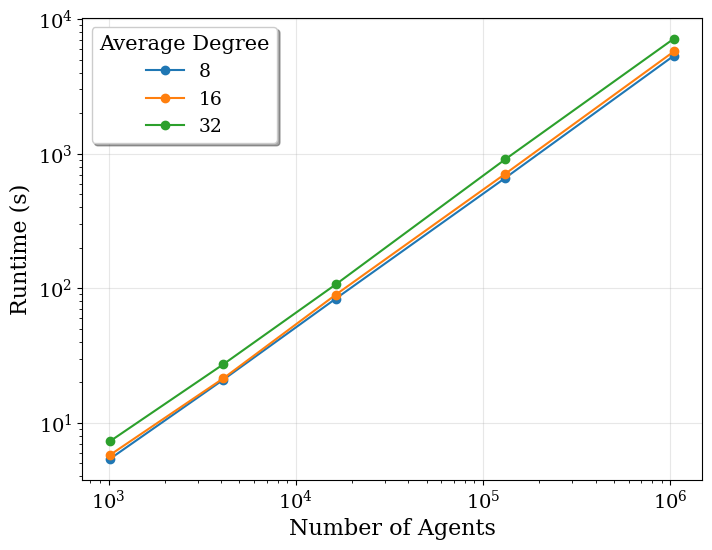

In [30]:
for i,nne in enumerate(profiling_result["time"]):
    plt.plot(
        list(profiling_result["time"][2].keys()),
        list(profiling_result["time"][nne].values()),
        label=profiling_result["avg_deg"][i],
        marker='o'
    )
plt.legend(shadow=True, title="Average Degree")
plt.yscale("log")
plt.xscale("log")
plt.xlabel("Number of Agents")
plt.ylabel("Runtime (s)")
# plt.savefig("profiling.pdf", bbox_inches="tight")

plt.show()

In [ ]:
# dist = []
# u, v = model.graph.edges()
# x_u = model.graph.ndata['x'][u]
# y_u = model.graph.ndata['y'][u]
# x_v = model.graph.ndata['x'][v]
# y_v = model.graph.ndata['y'][v]
# distance = torch.sqrt((x_u - x_v)**2 + (y_u - y_v)**2)
# plt.scatter(distance, model.graph.edata["weight"])
# plt.show()

# nx.draw(model.graph.to_networkx())

# plt.imshow(model.grid_environment.get_slice("population"), norm=LogNorm())
# plt.gca().invert_yaxixs()
# plt.scatter(model.graph.ndata['x'], model.graph.ndata['y'], c="red", s=10, alpha=0.3)
# plt.show()